<h2>Assignment 1</h2>

<table style="width:100%; text-align:left;">
<tr>
<td>

### Student 1  
**Name:** Aakanksha Deshpande  
**Student Id:** 25238088  

</td>

<td>

### Student 2  
**Name:** Vijayalaxmi Hubli  
**Student Id:** 25242017  

</td>
</tr>
</table>


## Task 1: Implement Logistic Regression

In [5]:
# Package imports
import matplotlib
import matplotlib.pyplot as plt
import sklearn
import sklearn.datasets
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [2]:
# Display plots inline
%matplotlib inline

In [3]:
# Initialising Hyperparameters

# alpha = 0.0001 # learning rate
# max_iterations = 10000
# threshold = 1e-8
# N = 500 # No of iterations

In [4]:
# Sigmoid Function (Activation Function)

def sigmoid(z):
    """
    Implementation of activation function
    Inputs:
    z (linear input)
    Outputs: 
    Binary classification returns probability value between 0 & 1
    """
    return (1 / (1 + (np.exp(-z))))

In [5]:
# Loss function
def compute_loss(y, y_hat):
    """
    Implementation of cross-entropy loss function

    Inputs:
    y = True Label (0 or 1)
    y_hat = Predicted probability (between 0 and 1)

    Output:
    Loss for the classification
    """
    return (- (y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))).item()

In [6]:
# Implementing Logistic Regression Algorithm

def train_logistic_regression(X, Y, alpha, max_iteration, threshold):
    """
    Logistic Regression Learning Algorithm with forward pass and Stochastic Gradient Descent

    Inputs:
    X = training dataset
    Y = target labels
    alpha = learning rate
    max_iteration = no of steps allowed for training
    threshold = stopping criteria

    Outputs:
    w = learned weights
    b = learned bias
    loss = loss calculated at per iteration
    epoch_loss = loss of a single epoch
    """
    #---------------------------------
    # Initialising parameters
    #---------------------------------
    np.random.seed(42)                        # To ensure same results everytime
    stopping = False                          # To exit the while loop once convergence is met
    J_running = 0                             # Represents cumulative loss of an epoch 
    epoch_number = 0                          # To keep a counter of epochs
    J_running_prev = 0                        # Represents previous epoch loss for convergence comparsion
    prev_avg_loss = float("inf")
    iteration = 0                             # To keep a counter of iterations     
    N,m = X.shape                             # N = no: of samples, m = no:of features
    w = np.random.normal(0, 0.01, size=(m,1)) # Small range of w & b choosen to avoid missing minima
    b = 0.01                                 

    #---------------------------------
    # Implementing SGD
    #---------------------------------
    loss = []
    epoch_loss = []
    while not stopping:

        # picking random values from training dataset
        index = np.random.randint(0, N)
        x_i = X[index].reshape(-1,1)
        y_i = Y[index]

        # Implementing Forward propagation stage
        z = np.dot(w.T, x_i) + b
        y_hat = sigmoid(z)

        # Calculate the loss
        J_current = compute_loss(y_i, y_hat)
        loss.append(J_current)
        # Gradient Descent stage: partial deivatives
        dw = (y_hat - y_i) * x_i
        db = y_hat - y_i

        # calculate w and b
        w -= alpha * dw
        b -= alpha * db

        # Checking stopping criteia
        iteration += 1
        J_running += J_current

        if iteration % N == 0:
            epoch_number += 1
            avg_loss = J_running / N
            epoch_loss.append(avg_loss)
            # print("Iteration:", iteration, "Avg Loss:", avg_loss)
            if abs(avg_loss - prev_avg_loss) < threshold:
                print(f"Converged after {epoch_number} epochs ({iteration} iterations)")
                stopping = True
            prev_avg_loss = avg_loss
            J_running = 0
        if iteration  > max_iteration:
            print("Failed to converge!!!")
            stopping = True # Failed to converge
        


    return w, b, loss, epoch_loss


In [7]:
def predict(X, w, b, threshold):
    """
    Implementation of prediction function

    Inputs:
    X = input features (Testing/validation dataset)
    w = weights (calculated at training stage)
    b = bias (also calculated at traing stage)
    threshold = decision threshold to classify 
    
    Outputs:
    Returns predicted class label based on threshold
    """
    z = np.dot(X, w) + b
    y_hat = sigmoid(z)
    return (y_hat >= threshold).astype(int)

## Task 2: Testing on Datasets

In [8]:
def split_data(X, y, random_state = 42):
    '''
    This function splits the entire dataset into 3 sections: train, test, validation
    train_test_split function has the ability to split the dataset into 2 sections initially (train & temp). 
    The temp data is then split again in 2 sections - test & validation.

    Inputs: 
    X, y
    Outputs: 
    X_train, Y_train, X_val, Y_val, X_test, Y_test
    '''
    X_train, X_temp, Y_train, Y_temp = train_test_split(
        X, y, test_size=0.3, random_state=random_state, stratify=y)

    X_val, X_test, Y_val, Y_test = train_test_split(
        X_temp, Y_temp, test_size=0.5, random_state=random_state, stratify=Y_temp)

    return X_train, Y_train, X_val, Y_val, X_test, Y_test

In [9]:
# Loading Dataset 1
# Use pandas to read the CSV file as a dataframe
df1 = pd.read_csv("/Users/aakankshadeshpande/Documents/Assignments_Sem2/blobs600.csv")

# The y values are those labelled 'Class': extract their values
y1 = df1['Class'].values

# The x values are all other columns
del df1['Class']   # drop the 'Class' column from the dataframe
X1 = df1.values     # convert the remaining columns to a numpy array

In [10]:
# Check its dimensions

print(f"The dimensions of the dataset are: {np.shape(X1)}")

The dimensions of the dataset are: (600, 3)


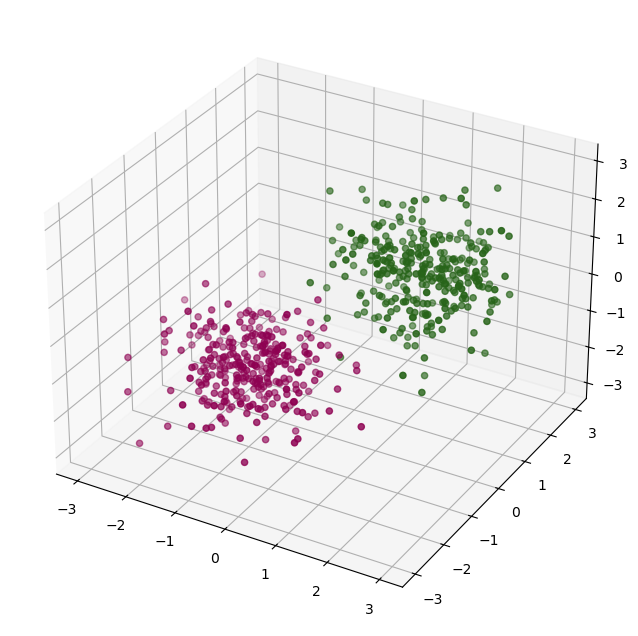

In [11]:
# Plot the dataset in 3D, with colours according to the class label

fig = plt.figure(figsize=(8, 8)) # set the size to 8x8 
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X1[:,0], X1[:,1], X1[:,2], c=y1, cmap="PiYG") # changed the colour map because why not

plt.show()
plt.close(fig)

In [12]:
#Splitting the training data & implementing logistic regression function on Dataset 1

X_train1, Y_train1, X_val1, Y_val1, X_test1, Y_test1 = split_data(X1, y1)
w1, b1, loss1, epoch_loss1 = train_logistic_regression(X_train1, Y_train1, alpha=0.01, max_iteration=20000, threshold=1e-3)
print(w1, b1, epoch_loss1)

Converged after 5 epochs (2100 iterations)
[[1.4913422 ]
 [1.28627418]
 [1.32349131]] [[-0.00392804]] [0.22564382348108486, 0.08648357526916561, 0.05680247064224819, 0.04308129438218171, 0.042499466083714715]


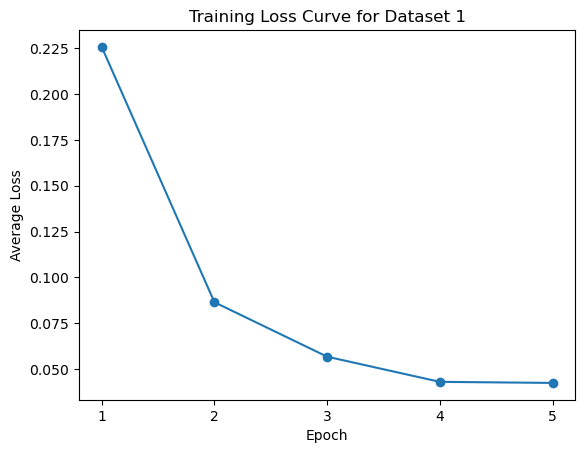

In [13]:
# plotting the Avg_Loss v/s Epoch on Training data for Dataset 1

plt.plot(range(1, len(epoch_loss1)+1), epoch_loss1, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.title("Training Loss Curve for Dataset 1")
plt.xticks(range(1, len(epoch_loss1)+1))
plt.show()

In [14]:
#implementing logistic regression function on Test data (Dataset 1)

test_w1, test_b1, test_loss1, test_epoch_loss1 = train_logistic_regression(X_test1, Y_test1, alpha=0.01, max_iteration=20000, threshold=1e-3)
print(test_w1, test_b1, test_epoch_loss1 )

Converged after 23 epochs (2070 iterations)
[[1.23874221]
 [1.41175115]
 [1.44380182]] [[0.05852494]] [0.45121652649575017, 0.25786924613554946, 0.15760244683124727, 0.13659224542906773, 0.12817424285964193, 0.08571970860002308, 0.08983851833983633, 0.08010750254676655, 0.06484724641206413, 0.057524031668980756, 0.06372891985684621, 0.06061849869267244, 0.05285569240810323, 0.0452156982176156, 0.037439024769457034, 0.033089467177136345, 0.03449992197071085, 0.040239886894227535, 0.03708797802902035, 0.042596080061579146, 0.03229614639225322, 0.03714034409645749, 0.036676373133749614]


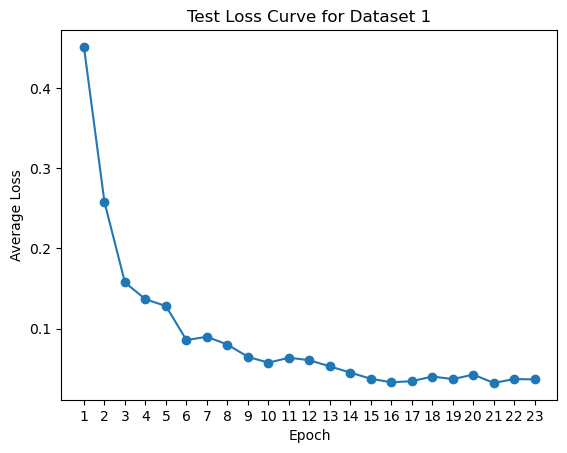

In [15]:
# plotting the Avg_Loss v/s Epoch on Test data for Dataset 1
plt.plot(range(1, len(test_epoch_loss1 )+1), test_epoch_loss1 , marker='o')
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.title("Test Loss Curve for Dataset 1")
plt.xticks(range(1, len(test_epoch_loss1 )+1))
plt.show()

In [16]:
#implementing logistic regression function on Validation data (Dataset 1)

val_w1, val_b1, val_loss1, val_epoch_loss1 = train_logistic_regression(X_val1, Y_val1, alpha=0.01, max_iteration=20000, threshold=1e-3)
print(val_w1, val_b1, val_epoch_loss1 )

Converged after 50 epochs (4500 iterations)
[[2.10920666]
 [1.57132778]
 [1.3430171 ]] [[-0.01361019]] [0.4631266005593651, 0.2511843516052567, 0.17568464000685746, 0.14520680884827183, 0.09595089848145225, 0.12634022175080092, 0.0914770832699346, 0.08248988252421609, 0.09606283222995458, 0.07346486367850687, 0.07552050027594241, 0.07283609013898017, 0.07507175628197457, 0.059700021872203426, 0.042860635282953495, 0.07876808460060611, 0.05986733431047771, 0.06767872900277375, 0.053216177479714716, 0.06466237619863209, 0.053256559593848146, 0.04821734788831199, 0.08779289138239675, 0.05755267034985075, 0.045277420332027134, 0.03534252232667177, 0.0618266340349289, 0.03225609529689441, 0.0451525495395594, 0.054162534733330325, 0.03622476553302742, 0.06418419478496572, 0.047226678906368454, 0.027873111889518767, 0.04654005341448823, 0.04481414709531353, 0.032934151855525444, 0.026957192367220825, 0.02908123704664834, 0.020067820697851624, 0.030483395825969713, 0.03528747030499535, 0.03953

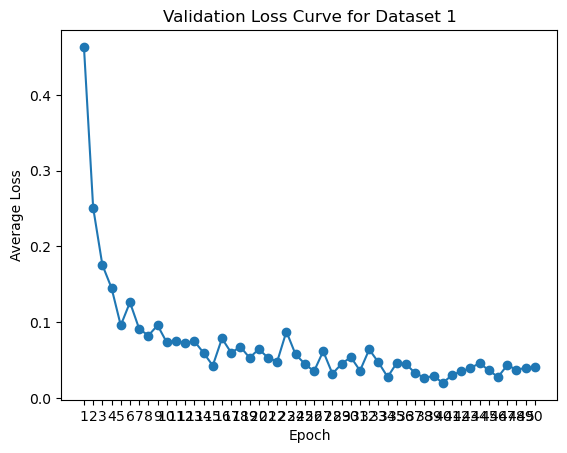

In [17]:
# plotting the Avg_Loss v/s Epoch on Validate data for Dataset 2
plt.plot(range(1, len(val_epoch_loss1 )+1), val_epoch_loss1 , marker='o')
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.title("Validation Loss Curve for Dataset 1")
plt.xticks(range(1, len(val_epoch_loss1 )+1))
plt.show()

In [18]:
# Validate and test performance
y1_val_pred = predict(X_val1, w1, b1, threshold = 0.5)
val_accuracy = np.mean(y1_val_pred == Y_val1) * 100
print(f"Validation Accuracy: {val_accuracy:.2f}%")
    
y1_test_pred = predict(X_test1, w1, b1, threshold = 0.5)
test_accuracy = np.mean(y1_test_pred == Y_test1) * 100
print(f"Test Accuracy: {test_accuracy:.2f}%")

Validation Accuracy: 50.00%
Test Accuracy: 50.00%


In [10]:
# Loading Dataset 2
# Use pandas to read the CSV file as a dataframe
df2 = pd.read_csv(r"C:\Users\anush\Downloads\circles500 (1).csv")

# The y values are those labelled 'Class': extract their values
y2 = df2['Class'].values

# The x values are all other columns
del df2['Class']   # drop the 'Class' column from the dataframe
X2 = df2.values     # convert the remaining columns to a numpy array

In [11]:
# Check its dimensions

print(f"The dimensions of Dataset 2 are: {np.shape(X2)}")

The dimensions of Dataset 2 are: (500, 2)


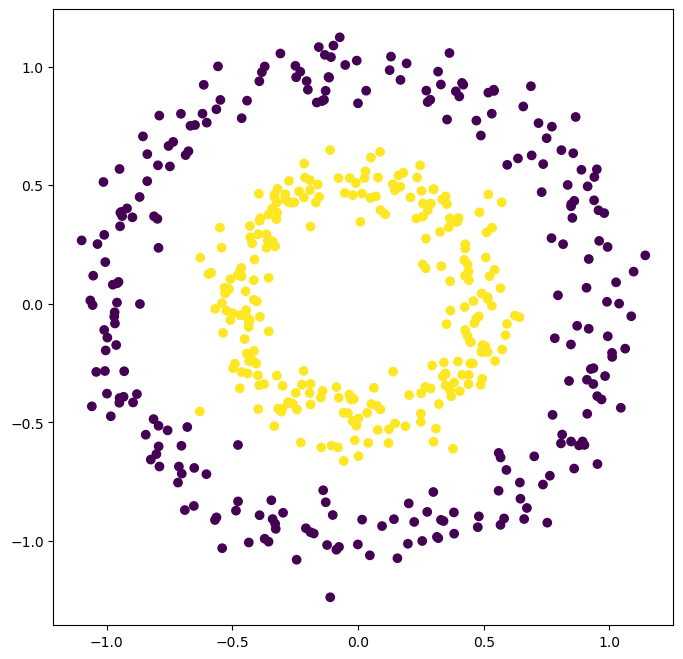

In [12]:
# plot X[0] vs X[1] and colour points according to the class, y

fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(X2[:,0], X2[:,1], c=y2)

plt.show()
plt.close(fig)

In [13]:
#Splitting the training data & implementing logistic regression function on Dataset 2

X_train2, Y_train2, X_val2, Y_val2, X_test2, Y_test2 = split_data(X2, y2)
w2, b2, loss2, epoch_loss2 = train_logistic_regression(X_train2, Y_train2, alpha=0.01, max_iteration=30000, threshold=1e-3)
print(w2, b2, epoch_loss2)

Converged after 6 epochs (2100 iterations)
[[ 0.00310505]
 [-0.11872224]] [[-0.0215474]] [0.6925089447815246, 0.6969922965110436, 0.6910863027247911, 0.6950824264293287, 0.6939740883415605, 0.6938309558136733]


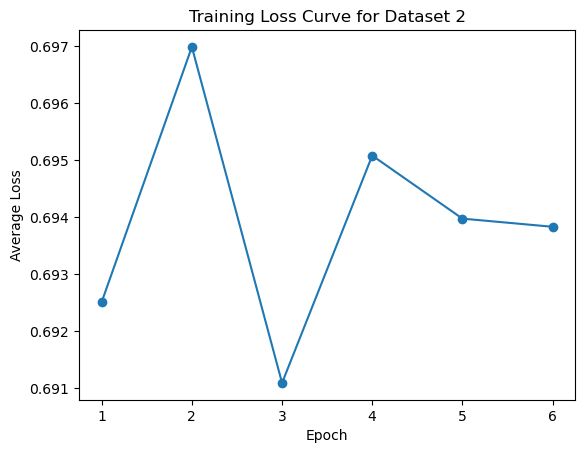

In [14]:
# plotting the Avg_Loss v/s Epoch on Training data for Dataset 2
plt.plot(range(1, len(epoch_loss2)+1), epoch_loss2, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.title("Training Loss Curve for Dataset 2")
plt.xticks(range(1, len(epoch_loss2)+1))
plt.show()

In [15]:
#implementing logistic regression function on Test data (Dataset 2)

test_w2, test_b2, test_loss2, test_epoch_loss2 = train_logistic_regression(X_test2, Y_test2, alpha=0.01, max_iteration=30000, threshold=1e-3)
print(test_w2, test_b2, test_epoch_loss2 )

Converged after 12 epochs (900 iterations)
[[-0.04943391]
 [ 0.29452545]] [[-3.38595738e-05]] [0.6926003212783644, 0.6855378443927986, 0.6939936366191359, 0.6975919024685802, 0.6819073110571929, 0.6771306705084529, 0.687065278426251, 0.6705809541205677, 0.6899457215345072, 0.7062243157405588, 0.6852402577546429, 0.6860077081967855]


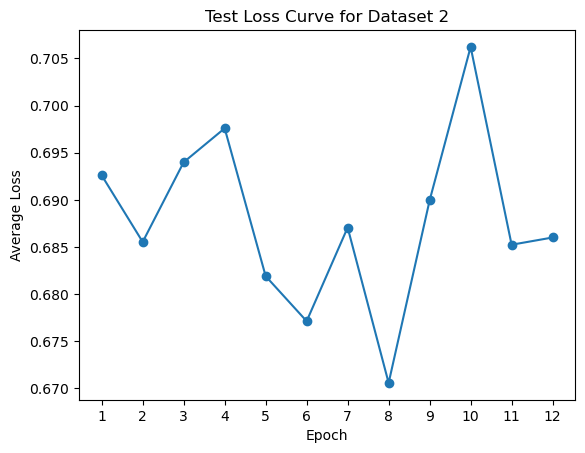

In [16]:
# plotting the Avg_Loss v/s Epoch on Test data for Dataset 2
plt.plot(range(1, len(test_epoch_loss2 )+1), test_epoch_loss2 , marker='o')
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.title("Test Loss Curve for Dataset 2")
plt.xticks(range(1, len(test_epoch_loss2 )+1))
plt.show()

In [17]:
#implementing logistic regression function on Validation data (Dataset 2)

val_w2, val_b2, val_loss2, val_epoch_loss2 = train_logistic_regression(X_val2, Y_val2, alpha=0.01, max_iteration=30000, threshold=1e-3)
print(val_w2, val_b2, val_epoch_loss2 )

Converged after 13 epochs (975 iterations)
[[0.06372969]
 [0.28471188]] [[0.15292065]] [0.6927811145031175, 0.6953641325845062, 0.692170934884475, 0.6891367455856537, 0.6869631195882694, 0.699701244758171, 0.68830165731672, 0.6943925228724417, 0.6814932836877612, 0.6879592695677276, 0.6817675827665258, 0.6769507997494212, 0.6772842074216765]


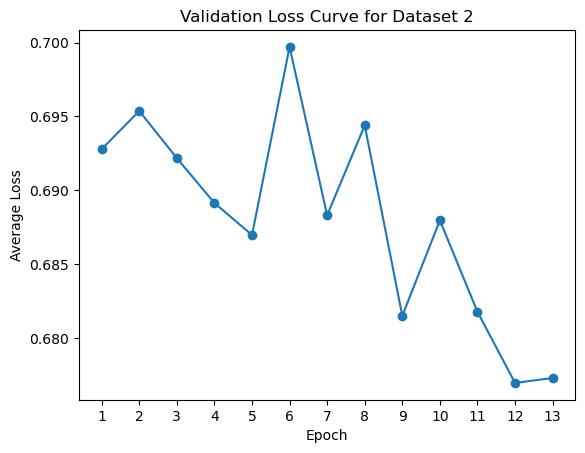

In [18]:
# plotting the Avg_Loss v/s Epoch on Validate data for Dataset 2
plt.plot(range(1, len(val_epoch_loss2 )+1), val_epoch_loss2 , marker='o')
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.title("Validation Loss Curve for Dataset 2")
plt.xticks(range(1, len(val_epoch_loss2 )+1))
plt.show()

In [19]:
# Validate and test performance
y2_val_pred = predict(X_val2, w2, b2, threshold = 1e-3)
val_accuracy = np.mean(y2_val_pred == Y_val2) * 100
print(f"Validation Accuracy: {val_accuracy:.2f}%")

y2_test_pred = predict(X_test2, w2, b2, threshold = 1e-3)
test_accuracy = np.mean(y2_test_pred == Y_test2) * 100
print(f"Test Accuracy: {test_accuracy:.2f}%")

Validation Accuracy: 50.67%
Test Accuracy: 49.33%


## Task 3: Implement and test a shallow Neural Network

In [19]:
def sigmoid_derivative(a):
    return a * (1 - a)

In [20]:
def initialize_network(n_inputs, n_hidden):
    np.random.seed(42)
    params = {}
    params['W1'] = np.random.randn(n_hidden, n_inputs) * 0.01
    params['b1'] = np.zeros((n_hidden, 1))
    params['W2'] = np.random.randn(1, n_hidden) * 0.01
    params['b2'] = np.zeros((1, 1))
    return params

In [21]:
def forward(x, params):
    z1 = np.dot(params['W1'], x) + params['b1']
    a1 = sigmoid(z1)
    z2 = np.dot(params['W2'], a1) + params['b2']
    a2 = sigmoid(z2)
    cache = {'x': x, 'z1': z1, 'a1': a1, 'z2': z2, 'a2': a2}
    return a2, cache

In [1]:
def backward(y, params, cache, learning_rate):
    x = cache['x']
    a1 = cache['a1']
    a2 = cache['a2']

    dz2 = a2 - y
    dW2 = np.dot(dz2, a1.T)
    db2 = dz2

    dz1 = np.dot(params['W2'].T, dz2) * sigmoid_derivative(a1)
    dW1 = np.dot(dz1, x.T)
    db1 = dz1

    # Update
    params['W2'] -= learning_rate * dW2
    params['b2'] -= learning_rate * db2
    params['W1'] -= learning_rate * dW1
    params['b1'] -= learning_rate * db1

    return params

In [9]:
def train_network(X, Y, n_hidden=2, learning_rate=0.1, epochs=1000):
    n_inputs = X.shape[0]                                                 #initialise parameters
    params = initialize_network(n_inputs, n_hidden)
    m = X.shape[1]
    losses = []

    for epoch in range(epochs):
        epoch_loss = 0
        for i in range(m):                                                #iterating thrrough each training example
            x = X[:, i:i+1]
            y = Y[:, i:i+1]
            a2, cache = forward(x, params)                                #forward pass
            params = backward(y, params, cache, learning_rate)            #backward pass
            epoch_loss += - (y * np.log(a2) + (1 - y) * np.log(1 - a2))   #computing loss

        if (epoch+1) % 100 == 0:                                          # monitoring loss at epoch level 
            loss_avg = np.mean(epoch_loss)
            losses.append(loss_avg)
            print(f"Epoch {epoch+1}, Loss: {loss_avg:.4f}")

    return params, losses


In [ ]:
#load dataset 1 + predict function

In [8]:
# circles500.csv → non-linear
circles = pd.read_csv(r"C:\Users\anush\Downloads\circles500 (1).csv")
X_circles = circles[['X0','X1']].values.T
Y_circles = circles['Class'].values.reshape(1,-1)

In [ ]:
plt.subplot(1,2,2)
plt.plot(np.arange(100, 15001, 100), losses_circles)
plt.title("Loss Curve - Circles")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.show()

## Task 4: Tackle a challenging task

## Task 5: Deep Learning Enhancements